## --- Google Colab environment setup ---

The cell below only needs to run when the notebook is opened in Google Colab.

This code will not affect code execution locally in VS-code + conda environment.

Google Colab starts each session with its own **preloaded versions** of common Python (currently 3.12.12) and Python packages (NumPy, SciPy, etc.).  
If we install different package versions once loaded, Python cannot switch to them while it is already running.

### What will happen
When you run the setup cell below in Google Colab:

1. The required package versions are installed
2. The runtime is **automatically restarted** so the new versions can be loaded  
3. You may see the message **“Your session crashed for an unknown reason.”**  
   → This is expected and normal

After the restart, rerun the notebook and check the **version check cell** to confirm package versions are correct.

### Runtime menu notes
- **Runtime → Restart session**  
  Restarts Python but keeps installed packages and saved files

- **Runtime → Disconnect and delete runtime**  
  Resets Colab completely to its default environment (packages will need to be reinstalled)

In [24]:
# ============================================================
# Google Colab environment setup (pinned versions)
# ============================================================

import sys
import os
import subprocess

if "google.colab" in sys.modules:
    print("Running in Google Colab")
    print("Python version:", sys.version.split()[0])

    # ---- Required package versions --------------------------
    requirements = {
        "numpy": "2.4.0",
        "scipy": "1.16.3",
        "matplotlib": "3.10.8",
        "pandas": "2.3.3",
        "plotly": "6.5.2"
    }

    # ---- Check currently loaded versions --------------------
    restart_needed = False

    for pkg, required_version in requirements.items():
        try:
            module = __import__(pkg)
            installed_version = module.__version__
        except Exception:
            installed_version = None

        print(f"{pkg}: {installed_version} (required: {required_version})")

        if installed_version != required_version:
            restart_needed = True

    # ---- Install if needed ----------------------------------
    if restart_needed:
        print("\nInstalling pinned package versions...")

        pip_args = [
            f"{pkg}=={ver}" for pkg, ver in requirements.items()
        ]

        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", *pip_args]
        )

        print("Installation complete.")
        print("Restarting runtime to load correct packages...")

        # This will appear as a "crash" in Colab — expected behavior
        os.kill(os.getpid(), 9)

    else:
        print("\nAll required package versions already installed.")

else:
    print("Not running in Google Colab — setup skipped.")
    print("Python version:", sys.version.split()[0])

Not running in Google Colab — setup skipped.
Python version: 3.12.12


In [25]:
# --- Version check ---
import numpy
import scipy
import matplotlib
import pandas
import plotly

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("plotly:", plotly.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
plotly: 6.5.2


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.set_printoptions(precision=3, suppress=True)


In [27]:
# Write any additional helper function(s) that you want to call from your plotting function

def frame_deflection(x, L, uy_i, th_i, uy_j, th_j):
    """
    Local transverse displacement uy(x) (cubic).
    """
    N1, N2, N3, N4 = frame_shape_functions(x, L)
    return N1 * uy_i + N2 * th_i + N3 * uy_j + N4 * th_j

def frame_shape_functions(x, L):
    """
    Cubic shape functions for transverse displacement (same as beam).
    x can be scalar or numpy array.
    """
    x = np.asarray(x, dtype=float)
    xi = x / L
    N1 = 1.0 - 3.0 * xi**2 + 2.0 * xi**3
    N2 = L * (xi - 2.0 * xi**2 + xi**3)
    N3 = 3.0 * xi**2 - 2.0 * xi**3
    N4 = L * (-xi**2 + xi**3)

    return N1, N2, N3, N4

In [28]:
def plot_deformed_frame_2d(nodes, elements, U, scale=1.0, npts=500):
    """
    Problem 2 — Frame

    Plot undeformed and deformed shape for a 2D frame

    Inputs
    ------
    nodes : dict
        {node_id: (x, y)}
    elements : dict
        {elem_id: (i, j)}
    U : array-like
        Global displacement vector with [ux, uy, th] per node
    scale : float
        Deformation scale factor
    npts : int
        Number of sample points per element

    Tasks
    -----
    1) Loop through elements
    2) Compute L, c, s
    3) Extract (ux_i, uy_i, th_i, ux_j, uy_j, th_j) from U
    4) Compute ux(x) (linear) and uy(x) (cubic)
    5) Transform local displacement to global
    6) Plot undeformed and deformed structures
    """

    # TODO: implement
    plt.figure(figsize=(3, 2.5), dpi=300)

    x_nodes = []
    y_nodes = []
    for x, y in nodes.values():
        x_nodes.append(x)
        y_nodes.append(y)
    plt.scatter(x_nodes, y_nodes)

    for i, j in elements.values():
        xi, yi = nodes[i]
        xj, yj = nodes[j]

        dx = xj - xi
        dy = yj - yi

        L = (dx*dx + dy*dy) ** 0.5
        c = dx / L
        s = dy / L

        ux_i = U[3 * i - 3]
        uy_i = U[3 * i - 2]
        theta_i = U[3 * i - 1]
        ux_j = U[3 * j - 3]
        uy_j = U[3 * j - 2]
        theta_j = U[3 * j - 1]

        uxlocal_i =  c * ux_i + s * uy_i
        uylocal_i = -s * ux_i + c * uy_i

        uxlocal_j =  c * ux_j + s * uy_j
        uylocal_j = -s * ux_j + c * uy_j

        dx = np.linspace(0.0, L, npts)

        x0 = xi + c * dx
        y0 = yi + s * dx

        # Axial interpolation
        ux_local = (1.0 - dx / L) * uxlocal_i + (dx / L) * uxlocal_j

        # Transverse interpolation
        uy_local = frame_deflection(dx, L, uylocal_i, theta_i, uylocal_j, theta_j)

        ux_global = c * ux_local - s * uy_local
        uy_global = s * ux_local + c * uy_local

        x1 = x0 + scale * ux_global
        y1 = y0 + scale * uy_global

        plt.plot(x0, y0)
        plt.plot(x1, y1)

    plt.axis("equal")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title("Frame Deformed Shape")
    plt.show()

# HW7 Question 2 Setup Stage

## 1. Define the structure

### 1.1 Node coordinates

- Node 1: $x_1=0 \quad y_1=0$
- Node 2: $x_2=0 \quad y_2=10\ \text{m}$
- Node 3: $x_3=8 \text{m} \quad y_3=10\ \text{m}$

### 1.2 Global DOFs

- Node 1: DOF1 $u_{1x}$, DOF2 $u_{1y}$, DOF3 $\theta_1$
- Node 2: DOF4 $u_{2x}$, DOF5 $u_{2y}$, DOF6 $\theta_2$
- Node 3: DOF7 $u_{3x}$, DOF8 $u_{3y}$, DOF9 $\theta_3$

### 1.3 Unit Setup

- Element 1: $(1\text{-}2)$, $L_1=4\ \text{m}$
- Element 2: $(2\text{-}3)$, $L_2=3\ \text{m}$


### 1.4 Restrained and Free DOFs

- Node 1 Fixed, $u_{1x}=u_{1y}=\theta_1=0$
- Node 3 Pin, $u_{3x}=u_{3y}=0,\ \theta_3 \quad \text{free}$

Free DOFs:
$$
\{\boldsymbol{u}_f\}=\{u_{2x},u_{2y},\theta_2,\theta_3\}=\{u_4,u_5,u_6,u_9\}
$$

Restrained DOFs:
$$
\{\boldsymbol{u}_r\}=\{u_{1x},u_{1y},\theta_1,u_{3x},u_{3y}\}=\{u_1,u_2,u_3,u_7,u_8\}
$$

### 1.5 Unit load

- Element 1: Distributed load throughout full span $q=24\ \text{kN/m}$
- Element 2: Point load at midpoint $P=75\ \text{kN}$

---


## 2. Materials info

- $E=200\ \text{GPa}$
- $A=4740\ \text{mm}^2=4.74 \times 10^{-3}\ \text{m}^2$
- $I=22.2\times 10^6\ \text{mm}^4=2.22\times 10^{-5}\ \text{m}^4$

Therefore:
$$
EA=(2.00\times 10^8)(4.74 \times 10^{-3})=9.48\times 10^5\ \text{kN}
$$
$$
EI=(2.00\times 10^8)(2.22\times 10^{-5})=4440\ \text{kN}\cdot\text{m}^2
$$




---


## 3. Beam Element Stiffness Matrix $\boldsymbol{k}^{(e)}$

2D Frame Stiffness Matrix:
$$
\boldsymbol{k}'=
\begin{bmatrix}
\frac{EA}{L} & 0 & 0 & -\frac{EA}{L} & 0 & 0 \\[2pt]
0 & \frac{12EI}{L^3} & \frac{6EI}{L^2} & 0 & -\frac{12EI}{L^3} & \frac{6EI}{L^2} \\[2pt]
0 & \frac{6EI}{L^2} & \frac{4EI}{L} & 0 & -\frac{6EI}{L^2} & \frac{2EI}{L} \\[2pt]
-\frac{EA}{L} & 0 & 0 & \frac{EA}{L} & 0 & 0 \\[2pt]
0 & -\frac{12EI}{L^3} & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & -\frac{6EI}{L^2} \\[2pt]
0 & \frac{6EI}{L^2} & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & \frac{4EI}{L}
\end{bmatrix}
$$

### 3.1 Element 1, ($L=10\ \text{m}$)
$$
\frac{EA}{L}= \frac{9.48\times 10^5}{10}=94800
$$
$$
\frac{12EI}{L^3}= \frac{12\times 4440}{10^3}=53.28
$$
$$
\frac{6EI}{L^2}= \frac{6\times 4440}{10^2}=266.4
$$
$$
\frac{4EI}{L}= \frac{4\times 4440}{10}=1776
$$
$$
\frac{2EI}{L}=888
$$

Therefore:
$$
\boldsymbol{k}_{(1)}=
\begin{bmatrix}
94800 & 0 & 0 & -94800 & 0 & 0\\
0 & 53.28 & 266.4 & 0 & -53.28 & 266.4\\
0 & 266.4 & 1776 & 0 & -266.4 & 888\\
-94800 & 0 & 0 & 94800 & 0 & 0\\
0 & -53.28 & -266.4 & 0 & 53.28 & -266.4\\
0 & 266.4 & 888 & 0 & -266.4 & 1776
\end{bmatrix}
$$

### 3.2 Element 2, ($L=8\ \text{m}$)
$$
\frac{EA}{L}=\frac{9.48\times 10^5}{8}=118500
$$
$$
\frac{12EI}{L^3}= \frac{12\times 4440}{8^3}=104.0625
$$
$$
\frac{6EI}{L^2}= \frac{6\times 4440}{8^2}=416.25
$$
$$
\frac{4EI}{L}= \frac{4\times 4440}{8}=2220
$$
$$
\frac{2EI}{L}=1110
$$

Therefore:
$$
\boldsymbol{k}_{(2)}=
\begin{bmatrix}
118500 & 0 & 0 & -118500 & 0 & 0\\
0 & 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
0 & 416.25 & 2220 & 0 & -416.25 & 1110\\
-118500 & 0 & 0 & 118500 & 0 & 0\\
0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$

---

## 4. Assemble global stiffness matrix $\boldsymbol{K}$

- Element 1 $\Rightarrow$ DOF [1,2,3,4,5,6] with $\boldsymbol{k}_{(1)}$
- Element 2 $\Rightarrow$ DOF [4,5,6,7,8,9] with $\boldsymbol{k}_{(2)}$

Therefore: 
$$
\boldsymbol{K}=
\begin{bmatrix}
53.28 & 0 & -266.4 & -53.28 & 0 & -266.4 & 0 & 0 & 0\\
0 & 94800 & 0 & 0 & -94800 & 0 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 266.4 & 0 & 888 & 0 & 0 & 0\\
-53.28 & 0 & 266.4 & 53.28 + 118500 & 0 & 266.4 & -118500 & 0 & 0\\
0 & -94800 & 0 & 0 & 94800 + 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
-266.4 & 0 & 888 & 266.4 & 416.25 & 1776 + 2220 & 0 & -416.25 & 1110\\
0 & 0 & 0 & -118500 & 0 & 0 & 118500 & 0 & 0\\
0 & 0 & 0 & 0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 0 & 0 & 0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$
$$
=\begin{bmatrix}
53.28 & 0 & -266.4 & -53.28 & 0 & -266.4 & 0 & 0 & 0\\
0 & 94800 & 0 & 0 & -94800 & 0 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 266.4 & 0 & 888 & 0 & 0 & 0\\
-53.28 & 0 & 266.4 & 118553.28 & 0 & 266.4 & -118500 & 0 & 0\\
0 & -94800 & 0 & 0 & 94904.0625 & 416.25 & 0 & -104.0625 & 416.25\\
-266.4 & 0 & 888 & 266.4 & 416.25 & 3996 & 0 & -416.25 & 1110\\
0 & 0 & 0 & -118500 & 0 & 0 & 118500 & 0 & 0\\
0 & 0 & 0 & 0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 0 & 0 & 0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$

---

## 5. Build transformation matrices and compute global element stiffness

Displacement transform:
$$
\boldsymbol{u}'=\boldsymbol{T}\boldsymbol{u}^{(e)},
\qquad
\boldsymbol{T}=
\begin{bmatrix}
\cos\theta & \sin\theta & 0 & 0 & 0 & 0\\
-\sin\theta & \cos\theta & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & \cos\theta & \sin\theta & 0\\
0 & 0 & 0 & -\sin\theta & \cos\theta & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

Global element stiffness:
$$
\boldsymbol{k}=\boldsymbol{T}^T\boldsymbol{k}'\boldsymbol{T}
$$

### Element angles
- Element 1: $\theta=90^\circ \Rightarrow \cos\theta=0,\ \sin\theta=1$
- Element 2: $\theta=0^\circ \Rightarrow \text{Local coordinates are aligned with global coordinates}$


---

## 6. Partition DOFs into free and restrained

$$
\left[
\begin{array}{cccc|ccccc}
118553.28 & 0 & 266.4 & 0 & -53.28 & 0 & 266.4 & -118500 & 0\\
0 & 94904.0625 & 416.25 & 416.25 & 0 & -94800 & 0 & 0 & -104.0625\\
266.4 & 416.25 & 3996 & 1110 & -266.4 & 0 & 888 & 0 & -416.25\\
0 & 416.25 & 1110 & 2220 & 0 & 0 & 0 & 0 & -416.25\\ \hline
-53.28 & 0 & -266.4 & 0 & 53.28 & 0 & -266.4 & 0 & 0\\
0 & -94800 & 0 & 0 & 0 & 94800 & 0 & 0 & 0\\
266.4 & 0 & 888 & 0 & -266.4 & 0 & 1776 & 0 & 0\\
-118500 & 0 & 0 & 0 & 0 & 0 & 0 & 118500 & 0\\
0 & -104.0625 & -416.25 & -416.25 & 0 & 0 & 0 & 0 & 104.0625
\end{array}
\right]
\left\{
\begin{array}{c}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3\\ \hline
0\\
0\\
0\\
0\\
0
\end{array}
\right\}=
\left\{
\begin{array}{c}
0\\
0\\
0\\
0\\ \hline
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{array}
\right\}
-\boldsymbol{F}_f^F-\boldsymbol{F}_f^S-\boldsymbol{F}_f^H-\boldsymbol{F}_f^E
$$


---

## 7. FEFs and $\boldsymbol{F}^F$

### 7.1 Element 1: uniform load $q_x=24$ kN/m to global $+x$

Distributed load throughout the span:
$$
F_1=F_2=\frac{qL}{2}=120\ \text{kN}
$$
$$
M_1=+\frac{qL^2}{12}=200\ \text{kNm},\qquad
M_2=-\frac{qL^2}{12}=-200\ \text{kNm}
$$

$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0\\
120\\
200\\
0\\
120\\
-200
\end{bmatrix}
$$

Transform to global:
$$
\boldsymbol{F}^{F}_{(1)}=\boldsymbol{T}_1^T\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}
$$

### 7.2 Element 2: midspan point load $P=75$ kN downward

Point load at midspan:
$$
F_2=F_3=\frac{P}{2}=37.5\ \text{kN}
$$
$$
M_2=+\frac{PL}{8}=75\ \text{kNm},\qquad
M_3=-\frac{PL}{8}=-75\ \text{kNm}
$$


Thus:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
$$

Since local coordinates are aligned with global coordinates:
$$
\boldsymbol{F}^{F}_{(2)}=\boldsymbol{Q}^{F}_{(2)}
$$

### 7.3 Assemble the global $\boldsymbol{F}^F$ (size 9)
  
$$
\boldsymbol{F}^{F}_{(1)}=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
4\\
5\\
6
\end{bmatrix}
$$

$$
\boldsymbol{F}^{F}_{(2)}=
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
4\\
5\\
6\\
7\\
8\\
9
\end{bmatrix}
$$

$$
\boldsymbol{F}^F=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
37.5\\
-125\\
0\\
37.5\\
-75
\end{bmatrix}
$$


---
---

# Question 1 — Support Displacements

---

## 8. Solve for unknown displacements

The solution for the unknown displacements at the free DOFs:

$$
\boldsymbol{u_f} = \boldsymbol{K}_{ff}^{-1}\left(\boldsymbol{F}_f - \boldsymbol{F}_f^{F} - \boldsymbol{K}_{fr}\boldsymbol{u}_r\right)
$$

where

$$
\boldsymbol{F}=\boldsymbol{0} \qquad 
$$

From the problem statement:

- bottom-left support rotation: $\theta_1=+0.01\ \text{rad}$
- top-right pin support moves $5\ \text{mm}$ to the right
- top-right pin support moves $10\ \text{mm}$ downward

$$
\boldsymbol{u}_r=
\begin{bmatrix}
0\\
0\\
0.01\\
0.005\\
-0.01\\
\end{bmatrix}
\left(
\begin{array}{c}
\text{m}\\
\text{m}\\
\text{rad}\\
\text{m}\\
\text{m}
\end{array}
\right)
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
7\\
8
\end{bmatrix}
$$

Given

$$
\boldsymbol{K}_{fr}=
\begin{bmatrix}
-53.28 & 0 & 266.4 & -118500 & 0\\
0 & -94800 & 0 & 0 & -104.0625\\
-266.4 & 0 & 888 & 0 & -416.25\\
0 & 0 & 0 & 0 & -416.25
\end{bmatrix}
$$

Therefore
$$
\boldsymbol{F}^{S}_{f}
=
\boldsymbol{K}_{fr}\boldsymbol{u}_r
=
\begin{bmatrix}
-53.28 & 0 & 266.4 & -118500 & 0\\
0 & -94800 & 0 & 0 & -104.0625\\
-266.4 & 0 & 888 & 0 & -416.25\\
0 & 0 & 0 & 0 & -416.25
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0.01\\
0.005\\
-0.01\\
\end{bmatrix}
=
\begin{bmatrix}
-589.836\\
1.040625\\
13.0425\\
4.1625
\end{bmatrix}
$$

Therefore
$$
\boldsymbol{F}_f^F+\boldsymbol{F}_f^S=
\begin{bmatrix}
-589.836\\
1.040625\\
13.0425\\
4.1625
\end{bmatrix}
+
\begin{bmatrix}
-120\\
37.5\\
-125\\
-75
\end{bmatrix}
=
\begin{bmatrix}
-709.836\\
38.540625\\
-111.9575\\
-70.8375
\end{bmatrix}
$$

Given
$$
\boldsymbol{K}_{ff}=
\begin{bmatrix}
118553.28 & 0 & 266.4 & 0\\
0 & 94904.0625 & 416.25 & 416.25\\
266.4 & 416.25 & 3996 & 1110\\
0 & 416.25 & 1110 & 2220
\end{bmatrix}
$$

Therefore:
$$
\begin{bmatrix}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3
\end{bmatrix}=
\begin{bmatrix}
8.436\times 10^{-6} & 1.434\times 10^{-9} & -6.532\times 10^{-7} & 3.263\times 10^{-7}\\
1.434\times 10^{-9} & 1.055\times 10^{-5} & -6.380\times 10^{-7} & -1.659\times 10^{-6}\\
-6.532\times 10^{-7} & -6.380\times 10^{-7} & 2.907\times 10^{-4} & -1.452\times 10^{-4}\\
3.263\times 10^{-7} & -1.659\times 10^{-6} & -1.452\times 10^{-4} & 5.234\times 10^{-4}
\end{bmatrix}
\begin{bmatrix}
709.836\\
-38.540625\\
111.9575\\
70.8375
\end{bmatrix}=
\begin{bmatrix}
0.00593810\\
−0.00059453\\
0.02182136\\
0.02111568​
\end{bmatrix}
\left(
\begin{array}{c}
\text{m}\\
\text{m}\\
\text{rad}\\
\text{rad}
\end{array}
\right)
$$
​

---

## 9. Recover support reactions

The solution for the unknown reactions at the restrained DOFs:
$$
\boldsymbol{F}_r = \boldsymbol{K}_{rf}\boldsymbol{u}_f + \boldsymbol{K}_{rr}\boldsymbol{u}_r +\boldsymbol{F}_r^F
$$

where

$$
\boldsymbol{K}_{rr}=
\begin{bmatrix}
53.28 & 0 & -266.4 & 0 & 0\\
0 & 94800 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 0 & 0\\
0 & 0 & 0 & 118500 & 0\\
0 & 0 & 0 & 0 & 104.0625
\end{bmatrix},
\qquad
\boldsymbol{u}_r=
\begin{bmatrix}
0\\
0\\
0.01\\
0.005\\
-0.01\\
\end{bmatrix}
$$

Result (restrained DOFs $[1,2,3,7,8]$):
$$
\begin{bmatrix}
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{bmatrix}=
\begin{bmatrix}
-53.28 & 0 & -266.4 & 0\\
0 & -94800 & 0 & 0\\
266.4 & 0 & 888 & 0\\
-118500 & 0 & 0 & 0\\
0 & -104.0625 & -416.25 & -416.25
\end{bmatrix}
\begin{bmatrix}
0.00593810\\
−0.00059453\\
0.02182136\\
0.02111568​
\end{bmatrix}+
\begin{bmatrix}
53.28 & 0 & -266.4 & 0 & 0\\
0 & 94800 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 0 & 0\\
0 & 0 & 0 & 118500 & 0\\
0 & 0 & 0 & 0 & 104.0625
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0.01\\
0.005\\
-0.01\\
\end{bmatrix}+
\begin{bmatrix}
-120\\
0\\
200\\
0\\
37.5
\end{bmatrix}=
\begin{bmatrix}
−128.79359227\\
56.36144400\\
238.71927752\\
−111.16485000\\
18.64870038​
\end{bmatrix}
\left(
\begin{array}{c}
\text{kN}\\
\text{kN}\\
\text{kNm}\\
\text{kN}\\
\text{kN}
\end{array}
\right)
$$

Therefore:
- Node 1 (Fixed)
  - Horizontal reaction: $F_{1x}=-128.794\ \text{kN}$
  - Vertical reaction $F_{1y}=56.361\ \text{kN}$
  - Bending moment: $M_1=238.719\ \text{kNm}$


- Node 3 (Pin)
  - Horizontal reaction: $F_{3x}=-111.165\ \text{kN}$
  - Vertical reaction $F_{3y}=18.649\ \text{kN}$

---

## 10. Global equilibrium check
### 10.1 Force Equilibrium
Total external loads:
- Horizontal: 
$$24\times 10=240 \text{kN}$$
- Vertical: $-75\text{kN}$

Total reactions:
- Horizontal: 
$$
F_{1x}+F_{3x}= -128.794-111.165=-239.959\text{kN}
$$
- Vertical:
$$
F_{1y}+F_{3y}= 56.361+18.649=75.010\text{kN}
$$

Sanity Check:
- Horizontal: 
$$
-239.959+240 =0.041
$$
- Vertical:
$$
75.010-75=0.010
$$

### 10.2 Moment Equilibrium (Take Node 1 as the geometric center)

Total external load moment: 
- Point load:
$$-75\times 4=-300 \text{kNm}$$
- Distributed load:
$$-240\times5 =-1200 \text{kNm}$$

Total reactions: 
$$
M_1 + 8\times F_{3y}-10\times F_{3x}=
238.719 + 8\times 18.649-10\times (-111.165)=
1499.561\ \text{kNm}
$$

Sanity Check:
$$
1499.561-1500 =-0.439\ \text{kNm}
$$

---

## 11. Element global displacement vectors

### 11.1 Element 1

$$
\boldsymbol{u}_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0\\0\\
0.01\\
0.00593810\\
−0.00059453\\
0.02182136\\
\end{bmatrix}
$$

### 11.2 Element 2

$$
\boldsymbol{u}_{(2)}=
\begin{bmatrix}
u_{2x}\\u_{2y}\\\theta_2\\u_{3x}\\u_{3y}\\\theta_3
\end{bmatrix}=
\begin{bmatrix}
0.00593810\\
−0.00059453\\
0.02182136\\
0.005\\-0.01\\0.02111568​
\end{bmatrix}
$$


---

## 12. Transform displacements to local coordinates

Element 1 ($\theta=90^\circ$):
$$
\boldsymbol{u}'_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
0\\0\\0.01\\
0.00593810\\
−0.00059453\\
0.02182136\\
\end{bmatrix}=
\begin{bmatrix}
0\\
0\\
0.01\\
−0.00059453\\
-0.00593810\\
0.02182136
\end{bmatrix}
$$

Element 2 ($\theta=0^\circ$, so $\boldsymbol{T}=\boldsymbol{I}$):
$$
\boldsymbol{u}'_{(2)}=
\begin{bmatrix}
0.00593810\\
−0.00059453\\
0.02182136\\
0.005\\-0.01\\0.02111568​
\end{bmatrix}
$$


---

## 13. Transform FEFs to local coordinates

Element 1:
$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}=
\begin{bmatrix}
0\\120\\200\\0\\120\\-200
\end{bmatrix}
$$

Element 2:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\37.5\\75\\0\\37.5\\-75
\end{bmatrix}
$$

---

## 14. Compute local element end forces/moments


### 14.1 Element 1

$$
\boldsymbol{f}'_{(1)}=
\begin{bmatrix}
94800 & 0 & 0 & -94800 & 0 & 0\\
0 & 53.28 & 266.4 & 0 & -53.28 & 266.4\\
0 & 266.4 & 1776 & 0 & -266.4 & 888\\
-94800 & 0 & 0 & 94800 & 0 & 0\\
0 & -53.28 & -266.4 & 0 & 53.28 & -266.4\\
0 & 266.4 & 888 & 0 & -266.4 & 1776
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0.01\\
−0.00059453\\
-0.00593810\\
0.02182136
\end{bmatrix}
+
\begin{bmatrix}
0\\
120\\
200\\
0\\
120\\
-200
\end{bmatrix}=
\begin{bmatrix}
56.361\\
128.794\\
238.719\\
-56.361\\
111.206\\
-150.783
\end{bmatrix}
$$

### 14.2 Element 2

$$
\boldsymbol{f}'_{(2)}=
\begin{bmatrix}
118500 & 0 & 0 & -118500 & 0 & 0\\
0 & 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
0 & 416.25 & 2220 & 0 & -416.25 & 1110\\
-118500 & 0 & 0 & 118500 & 0 & 0\\
0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
\begin{bmatrix}
0.00593810\\
−0.00059453\\
0.02182136\\
0.005\\-0.01\\0.02111568​
\end{bmatrix}+
\begin{bmatrix}
0\\37.5\\75\\0\\37.5\\-75
\end{bmatrix}=
\begin{bmatrix}
111.165\\
56.351\\
150.797\\
-111.165\\
18.649\\
0.0135
\end{bmatrix}
$$


---

## 15. Deformed shape (plot original vs deformed)

Python snippet (plots in one figure; includes an auto scale factor for visibility):



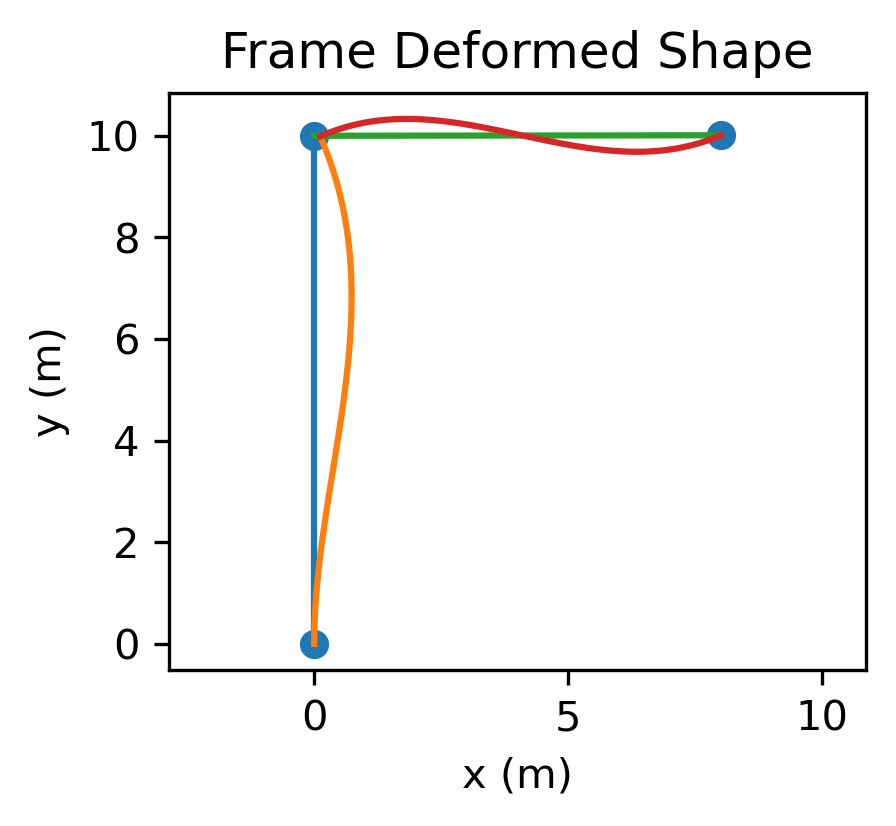

In [29]:
# Define nodes, elements, and U for your beam example

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.005, 10.01)
}
elements = {
    1: (1, 2),
    2: (2, 3)
}
U = [
    0.0, 0.0, 0.0,
    0.00593810, -0.00059453, 0.02182136,
    0.0, 0.0, 0.02111568
    ]

plot_deformed_frame_2d(nodes, elements, U, scale=20, npts=500)
# Then call plot_deformed_frame_2d(...)

---
---

# Question 2 — Temperature Effects

---

## 8. Equivalent Fixed-End Forces $\boldsymbol{F}^H$

Given

$\alpha = 12\times 10^{-6}/^\circ\mathrm{C}$

### 8.1 Element 1: uniform temperature increase of **+10°C**

Uniform temperature increase of +10°C:
$$
EA\alpha T_u
=
(9.48\times 10^5)(12\times 10^{-6})(10)
=
113.76\ \text{kN}
$$

Thus

$$
\boldsymbol{Q}^{H}_{(1)}=
\begin{bmatrix}
113.76\\
0\\
0\\
-113.76\\
0\\
0
\end{bmatrix}
$$

Transform to global:
$$
\boldsymbol{F}^{H}_{(1)}=\boldsymbol{T}_1^T\boldsymbol{Q}^{H}_{(1)}=
\begin{bmatrix}
0\\
113.76\\
0\\
0\\
-113.76\\
0
\end{bmatrix}
$$

### 8.2 Element 2: temperature gradient of **+15°C at the top** and **+5°C at the bottom**

$$
EA\alpha\left(\frac{T_b + T_t}{2}\right)=
(9.48\times 10^5)(12\times 10^{-6})\left(\frac{15 + 5}{2}\right)
=
113.76\ \text{kN}
$$

$$
EI\alpha\left(\frac{T_b - T_t}{d}\right)=
4440(12\times 10^{-6})\left(\frac{5 - 15}{0.3}\right)
=
-1.776\ \text{kNm}
$$


Thus:
$$
\boldsymbol{Q}^{H}_{(2)}=
\begin{bmatrix}
113.76\\
0\\
-1.776\\
-113.76\\
0\\
1.776
\end{bmatrix}
$$

Since local coordinates are aligned with global coordinates:
$$
\boldsymbol{F}^{H}_{(2)}=\boldsymbol{Q}^{H}_{(2)}
$$

### 8.3 Assemble the global $\boldsymbol{F}^F$ (size 9)
  
$$
\boldsymbol{F}^{H}_{(1)}=
\begin{bmatrix}
0\\
113.76\\
0\\
0\\
-113.76\\
0
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
4\\
5\\
6
\end{bmatrix}
$$

$$
\boldsymbol{F}^{H}_{(2)}=
\begin{bmatrix}
113.76\\
0\\
-1.776\\
-113.76\\
0\\
1.776
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
4\\
5\\
6\\
7\\
8\\
9
\end{bmatrix}
$$

$$
\boldsymbol{F}^F=
\begin{bmatrix}
0\\
113.76\\
0\\
113.76\\
-113.76\\
-1.776\\
-113.76\\
0\\
1.776
\end{bmatrix}
$$


---

## 9. Solve for unknown displacements

The solution for the unknown displacements at the free DOFs:

$$
\boldsymbol{u_f} = \boldsymbol{K}_{ff}^{-1}\left(\boldsymbol{F}_f - \boldsymbol{F}_f^{F} - \boldsymbol{K}_{fr}\boldsymbol{u}_r  - \boldsymbol{F}_f^{H}\right)
$$

where

$$
\boldsymbol{F}=\boldsymbol{0} \qquad \boldsymbol{u}_r=\boldsymbol{0}
$$

Therefore
$$
\boldsymbol{K}_{ff}\boldsymbol{u}_f=\boldsymbol{F}_f-\boldsymbol{F}_f^F = -\boldsymbol{F}_f^F   - \boldsymbol{F}_f^{H}
$$

Given
$$
\boldsymbol{K}_{ff}=
\begin{bmatrix}
118553.28 & 0 & 266.4 & 0\\
0 & 94904.0625 & 416.25 & 416.25\\
266.4 & 416.25 & 3996 & 1110\\
0 & 416.25 & 1110 & 2220
\end{bmatrix},
\qquad
\boldsymbol{F}_f^F=
\begin{bmatrix}
-120\\
37.5\\
-125\\
-75
\end{bmatrix},
\qquad
\boldsymbol{F}_f^H=
\begin{bmatrix}
113.76\\
-113.76\\
-1.776\\
1.776
\end{bmatrix}
$$

Therefore:
$$
\begin{bmatrix}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3
\end{bmatrix}=
\begin{bmatrix}
8.436\times 10^{-6} & 1.434\times 10^{-9} & -6.532\times 10^{-7} & 3.263\times 10^{-7}\\
1.434\times 10^{-9} & 1.055\times 10^{-5} & -6.380\times 10^{-7} & -1.659\times 10^{-6}\\
-6.532\times 10^{-7} & -6.380\times 10^{-7} & 2.907\times 10^{-4} & -1.452\times 10^{-4}\\
3.263\times 10^{-7} & -1.659\times 10^{-6} & -1.452\times 10^{-4} & 5.234\times 10^{-4}
\end{bmatrix}
\begin{bmatrix}
6.24\\
76.26\\
126.776\\
73.224
\end{bmatrix}=
\begin{bmatrix}
-0.00000617\\
0.00060199\\
0.02616691\\
0.01978745
\end{bmatrix}
\left(
\begin{array}{c}
\text{m}\\
\text{m}\\
\text{rad}\\
\text{rad}
\end{array}
\right)
$$


---

## 10. Recover support reactions

The solution for the unknown reactions at the restrained DOFs:
$$
\boldsymbol{F}_r = \boldsymbol{K}_{rf}\boldsymbol{u}_f + \boldsymbol{K}_{rr}\boldsymbol{u}_r +\boldsymbol{F}_r^F +\boldsymbol{F}_r^H
$$

where

$$
\boldsymbol{u}_r=\boldsymbol{0}
$$

Result (restrained DOFs $[1,2,3,7,8]$):
$$
\begin{bmatrix}
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{bmatrix}=
\begin{bmatrix}
-53.28 & 0 & -266.4 & 0\\
0 & -94800 & 0 & 0\\
266.4 & 0 & 888 & 0\\
-118500 & 0 & 0 & 0\\
0 & -104.0625 & -416.25 & -416.25
\end{bmatrix}
\begin{bmatrix}
-0.00000617\\
0.00060199\\
0.02616691\\
0.01978745
\end{bmatrix}+
\begin{bmatrix}
-120\\
0\\
200\\
0\\
37.5
\end{bmatrix}+
\begin{bmatrix}
0\\
113.76\\
0\\
-113.76\\
0\\
\end{bmatrix}=
\begin{bmatrix}
-126.97053609\\
56.69134800\\
223.23457239\\
-113.02885500\\
18.30885307
\end{bmatrix}
\left(
\begin{array}{c}
\text{kN}\\
\text{kN}\\
\text{kNm}\\
\text{kN}\\
\text{kN}
\end{array}
\right)
$$

Therefore:
- Node 1 (Fixed)
  - Horizontal reaction: $F_{1x}=-126.971\ \text{kN}$
  - Vertical reaction $F_{1y}=56.691\ \text{kN}$
  - Bending moment: $M_1=223.235\ \text{kNm}$


- Node 3 (Pin)
  - Horizontal reaction: $F_{3x}=-113.029\ \text{kN}$
  - Vertical reaction $F_{3y}=18.309\ \text{kN}$

---

## 11. Global equilibrium check
### 11.1 Force Equilibrium
Total external loads:
- Horizontal: 
$$24\times 10=240 \text{kN}$$
- Vertical: $-75\text{kN}$

Total reactions:
- Horizontal: 
$$
F_{1x}+F_{3x}= -126.971-113.029=-240\text{kN}
$$
- Vertical:
$$
F_{1y}+F_{3y}= 56.691+18.309=75\text{kN}
$$

Sanity Check:
- Horizontal: 
$$
-240+240 =0
$$
- Vertical:
$$
75-75=0
$$

### 11.2 Moment Equilibrium (Take Node 1 as the geometric center)

Total external load moment: 
- Point load:
$$-75\times 4=-300 \text{kNm}$$
- Distributed load:
$$-240\times5 =-1200 \text{kNm}$$

Total reactions: 
$$
M_1 + 8\times F_{3y}-10\times F_{3x}=
223.235 + 8\times 18.309-10\times (-113.029)=
1499.997\ \text{kNm}
$$

Sanity Check:
$$
1499.997-1500 =0.003 \text{kNm}
$$

---

## 12. Element global displacement vectors

### 12.1 Element 1

$$
\boldsymbol{u}_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0\\0\\0\\
-0.00000617\\
0.00060199\\
0.02616691
\end{bmatrix}
$$

### 12.2 Element 2

$$
\boldsymbol{u}_{(2)}=
\begin{bmatrix}
u_{2x}\\u_{2y}\\\theta_2\\u_{3x}\\u_{3y}\\\theta_3
\end{bmatrix}=
\begin{bmatrix}
-0.00000617\\
0.00060199\\
0.02616691\\
0\\0\\0.01978745
\end{bmatrix}
$$


---

## 13. Transform displacements to local coordinates

Element 1 ($\theta=90^\circ$):
$$
\boldsymbol{u}'_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0\\
-0.00000617\\
0.00060199\\
0.02616691
\end{bmatrix}=
\begin{bmatrix}
0\\
0\\
0\\
-0.00060199\\
-0.00000617\\
0.02616691
\end{bmatrix}
$$

Element 2 ($\theta=0^\circ$, so $\boldsymbol{T}=\boldsymbol{I}$):
$$
\boldsymbol{u}'_{(2)}=
\begin{bmatrix}
-0.00000617\\
0.00060199\\
0.02616691\\
0\\0\\0.01978745
\end{bmatrix}
$$


---

## 14. Transform FEFs to local coordinates

Element 1:
$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}=
\begin{bmatrix}
0\\120\\200\\0\\120\\-200
\end{bmatrix}
$$

Element 2:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\37.5\\75\\0\\37.5\\-75
\end{bmatrix}
$$

---

## 15. Compute local element end forces/moments


### 15.1 Element 1

$$
\boldsymbol{f}'_{(1)}=
\begin{bmatrix}
94800 & 0 & 0 & -94800 & 0 & 0\\
0 & 53.28 & 266.4 & 0 & -53.28 & 266.4\\
0 & 266.4 & 1776 & 0 & -266.4 & 888\\
-94800 & 0 & 0 & 94800 & 0 & 0\\
0 & -53.28 & -266.4 & 0 & 53.28 & -266.4\\
0 & 266.4 & 888 & 0 & -266.4 & 1776
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0\\
0.00060199\\
0.00000617\\
0.02616691
\end{bmatrix}
+
\begin{bmatrix}
0\\
120\\
200\\
0\\
120\\
-200
\end{bmatrix}
+
\begin{bmatrix}
113.76\\
0\\
0\\
-113.76\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
56.691\\
126.971\\
223.235\\
-56.691\\
113.029\\
-153.529
\end{bmatrix}
$$


### 15.2 Element 2

$$
\boldsymbol{f}'_{(2)}=
\begin{bmatrix}
118500 & 0 & 0 & -118500 & 0 & 0\\
0 & 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
0 & 416.25 & 2220 & 0 & -416.25 & 1110\\
-118500 & 0 & 0 & 118500 & 0 & 0\\
0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
\begin{bmatrix}
-0.00000617\\
0.00060199\\
0.02616691\\
0\\0\\0.01978745
\end{bmatrix}+
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
+
\begin{bmatrix}
113.76\\
0\\
-1.776\\
-113.76\\
0\\
1.776`
\end{bmatrix}
=
\begin{bmatrix}
113.029\\
56.691\\
153.530\\
-113.029\\
18.309\\
0.000
\end{bmatrix}
$$


---

## 16. Deformed shape (plot original vs deformed)

Python snippet:



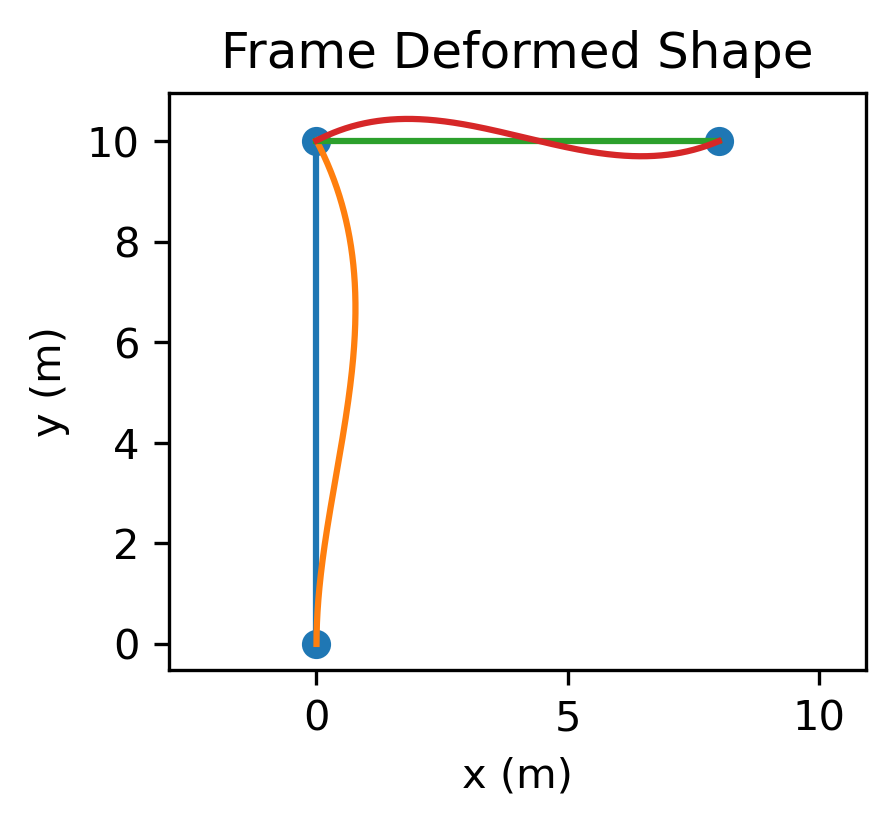

In [30]:
# Define nodes, elements, and U for your beam example

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0)
}
elements = {
    1: (1, 2),
    2: (2, 3)
}
U = [
    0.0, 0.0, 0.0,
    -0.00000617, 0.00060199, 0.02616691,
    0.0, 0.0, 0.02120070
]

plot_deformed_frame_2d(nodes, elements, U, scale=20, npts=500)
# Then call plot_deformed_frame_2d(...)

---
---

# Question 3 — Fabrication / Fit-up Errors

---

## 8. Equivalent Fixed-End Forces $\boldsymbol{F}^E$

The fabrication error is:

- vertical member: $3\ \text{mm}$ too short
- horizontal member: $3\ \text{mm}$ too short

Thus,

$$
e_a = -0.003\ \text{m}
$$


### 8.1 Element 1: $3\ \text{mm}$ too short
For a member length error,

$$
\boldsymbol{Q}^{E}_{(1)}
\frac{EA}{L}e_a
\begin{bmatrix}
1\\
0\\
0\\
-1\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
-284.4\\
0\\
0\\
284.4\\
0\\
0
\end{bmatrix}
$$

Transform to global:
$$
\boldsymbol{F}^{E}_{(1)}=\boldsymbol{T}_1^T\boldsymbol{Q}^{E}_{(1)}=
\begin{bmatrix}
0\\
-284.4\\
0\\
0\\
284.4\\
0
\end{bmatrix}
$$

### 8.2 Element 2: $3\ \text{mm}$ too short
For a member length error,

$$
\boldsymbol{Q}^{E}_{(2)}
\frac{EA}{L}e_a
\begin{bmatrix}
1\\
0\\
0\\
-1\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
-355.5\\
0\\
0\\
355.5\\
0\\
0
\end{bmatrix}
$$

Transform to global:
$$
\boldsymbol{F}^{E}_{(2)}=\boldsymbol{T}_2^T\boldsymbol{Q}^{E}_{(2)}=
\begin{bmatrix}
-355.5\\
0\\
0\\
355.5\\
0\\
0
\end{bmatrix}
$$

### 8.3 Assemble the global $\boldsymbol{F}^E$
  
$$
\boldsymbol{F}^{E}_{(1)}=
\begin{bmatrix}
0\\
-284.4\\
0\\
0\\
284.4\\
0
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
4\\
5\\
6
\end{bmatrix}
$$

$$
\boldsymbol{F}^{E}_{(2)}=
\begin{bmatrix}
-355.5\\
0\\
0\\
355.5\\
0\\
0
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
4\\
5\\
6\\
7\\
8\\
9
\end{bmatrix}
$$

$$
\boldsymbol{F}^E=
\begin{bmatrix}
0\\
-284.4\\
0\\
-355.5\\
284.4\\
0\\
355.5\\
0\\
0
\end{bmatrix}
$$


---

## 9. Solve for unknown displacements

The solution for the unknown displacements at the free DOFs:

$$
\boldsymbol{u_f} = \boldsymbol{K}_{ff}^{-1}\left(\boldsymbol{F}_f - \boldsymbol{F}_f^{F} - \boldsymbol{K}_{fr}\boldsymbol{u}_r - \boldsymbol{F}_f^{E}\right)
$$

where

$$
\boldsymbol{F}=\boldsymbol{0} \qquad \boldsymbol{u}_r=\boldsymbol{0}
$$

Therefore
$$
\boldsymbol{K}_{ff}\boldsymbol{u}_f=\boldsymbol{F}_f-\boldsymbol{F}_f^F-\boldsymbol{F}_f^E = -\boldsymbol{F}_f^F-\boldsymbol{F}_f^E
$$

Given
$$
\boldsymbol{K}_{ff}=
\begin{bmatrix}
118553.28 & 0 & 266.4 & 0\\
0 & 94904.0625 & 416.25 & 416.25\\
266.4 & 416.25 & 3996 & 1110\\
0 & 416.25 & 1110 & 2220
\end{bmatrix},
\qquad
\boldsymbol{F}_f^F=
\begin{bmatrix}
-120\\
37.5\\
-125\\
-75
\end{bmatrix}
\qquad
\boldsymbol{F}_f^E=
\begin{bmatrix}
-355.5\\
284.4\\
0\\
0
\end{bmatrix}
$$

$$
\boldsymbol{F}_{f}^{F}+\boldsymbol{F}_{f}^{E}
=
\begin{bmatrix}
-475.5\\
321.9\\
-125\\
-75
\end{bmatrix}
$$

Therefore:
$$
\begin{bmatrix}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3
\end{bmatrix}=
\begin{bmatrix}
8.436\times 10^{-6} & 1.434\times 10^{-9} & -6.532\times 10^{-7} & 3.263\times 10^{-7}\\
1.434\times 10^{-9} & 1.055\times 10^{-5} & -6.380\times 10^{-7} & -1.659\times 10^{-6}\\
-6.532\times 10^{-7} & -6.380\times 10^{-7} & 2.907\times 10^{-4} & -1.452\times 10^{-4}\\
3.263\times 10^{-7} & -1.659\times 10^{-6} & -1.452\times 10^{-4} & 5.234\times 10^{-4}
\end{bmatrix}
\begin{bmatrix}
475.5\\
-321.9\\
125\\
75
\end{bmatrix}=
\begin{bmatrix}
0.00395368\\
-0.00359954\\
0.02534228\\
0.02179419
\end{bmatrix}
\left(
\begin{array}{c}
\text{m}\\
\text{m}\\
\text{rad}\\
\text{rad}
\end{array}
\right)
$$


---

## 10. Recover support reactions

The solution for the unknown reactions at the restrained DOFs:
$$
\boldsymbol{F}_r = \boldsymbol{K}_{rf}\boldsymbol{u}_f + \boldsymbol{K}_{rr}\boldsymbol{u}_r +\boldsymbol{F}_r^F+\boldsymbol{F}_r^E
$$

where

$$
\boldsymbol{u}_r=\boldsymbol{0}
$$

Result (restrained DOFs $[1,2,3,7,8]$):
$$
\begin{bmatrix}
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{bmatrix}=
\begin{bmatrix}
-53.28 & 0 & -266.4 & 0\\
0 & -94800 & 0 & 0\\
266.4 & 0 & 888 & 0\\
-118500 & 0 & 0 & 0\\
0 & -104.0625 & -416.25 & -416.25
\end{bmatrix}
\begin{bmatrix}
0.00395368\\
-0.00359954\\
0.02534228\\
0.02179419
\end{bmatrix}+
\begin{bmatrix}
-120\\
0\\
200\\
0\\
37.5
\end{bmatrix}
+
\begin{bmatrix}
0\\
-284.4\\
0\\
355.5\\
0
\end{bmatrix}
=
\begin{bmatrix}
-126.96183546 \\
56.83639200 \\
223.55720499 \\
-113.01108000 \\
18.25402149
\end{bmatrix}
\left(
\begin{array}{c}
\text{kN}\\
\text{kN}\\
\text{kNm}\\
\text{kN}\\
\text{kN}
\end{array}
\right)
$$

Therefore:
- Node 1 (Fixed)
  - Horizontal reaction: $F_{1x}=-126.962\ \text{kN}$
  - Vertical reaction $F_{1y}=56.836\ \text{kN}$
  - Bending moment: $M_1=223.557\ \text{kNm}$


- Node 3 (Pin)
  - Horizontal reaction: $F_{3x}=-113.011\ \text{kN}$
  - Vertical reaction $F_{3y}=18.254\ \text{kN}$

---

## 11. Global equilibrium check
### 11.1 Force Equilibrium
Total external loads:
- Horizontal: 
$$24\times 10=240 \text{kN}$$
- Vertical: $-75\text{kN}$

Total reactions:
- Horizontal: 
$$
F_{1x}+F_{3x}= -126.962-113.011=-239.973\text{kN}
$$
- Vertical:
$$
F_{1y}+F_{3y}= 56.836+18.254=75.09\text{kN}
$$

Sanity Check:
- Horizontal: 
$$
-239.973+240 =0.027
$$
- Vertical:
$$
75.09-75=0.09
$$

### 11.2 Moment Equilibrium (Take Node 1 as the geometric center)

Total external load moment: 
- Point load:
$$-75\times 4=-300 \text{kNm}$$
- Distributed load:
$$-240\times5 =-1200 \text{kNm}$$

Total reactions: 
$$
M_1 + 8\times F_{3y}-10\times F_{3x}=
223.557 + 8\times 18.254-10\times (-113.011)=
1499.699\ \text{kNm}
$$

Sanity Check:
$$
1499.699-1500 =-0.301 \text{kNm}
$$

---

## 12. Element global displacement vectors

### 12.1 Element 1

$$
\boldsymbol{u}_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0\\0\\0\\
0.00395368\\
-0.00359954\\
0.02534228
\end{bmatrix}
$$

### 12.2 Element 2

$$
\boldsymbol{u}_{(2)}=
\begin{bmatrix}
u_{2x}\\u_{2y}\\\theta_2\\u_{3x}\\u_{3y}\\\theta_3
\end{bmatrix}=
\begin{bmatrix}
0.00395368\\
-0.00359954\\
0.02534228\\
0\\0\\0.02179419
\end{bmatrix}
$$


---

## 13. Transform displacements to local coordinates

Element 1 ($\theta=90^\circ$):
$$
\boldsymbol{u}'_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
0\\0\\0\\
0.00395368\\
-0.00359954\\
0.02534228
\end{bmatrix}=
\begin{bmatrix}
0\\
0\\
0\\
-0.00359954\\
-0.00395368\\
0.02534228
\end{bmatrix}
$$

Element 2 ($\theta=0^\circ$, so $\boldsymbol{T}=\boldsymbol{I}$):
$$
\boldsymbol{u}'_{(2)}=
\begin{bmatrix}
0.00395368\\
-0.00359954\\
0.02534228\\
0\\
0\\
0.02179419
\end{bmatrix}
$$


---

## 14. Transform FEFs to local coordinates

Element 1:
$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}=
\begin{bmatrix}
0\\120\\200\\0\\120\\-200
\end{bmatrix}
$$

Element 2:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\37.5\\75\\0\\37.5\\-75
\end{bmatrix}
$$

---

## 15. Compute local element end forces/moments


### 15.1 Element 1

$$
\boldsymbol{f}'_{(1)}=
\begin{bmatrix}
94800 & 0 & 0 & -94800 & 0 & 0\\
0 & 53.28 & 266.4 & 0 & -53.28 & 266.4\\
0 & 266.4 & 1776 & 0 & -266.4 & 888\\
-94800 & 0 & 0 & 94800 & 0 & 0\\
0 & -53.28 & -266.4 & 0 & 53.28 & -266.4\\
0 & 266.4 & 888 & 0 & -266.4 & 1776
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0\\
-0.00359954\\
-0.00395368\\
0.02534228
\end{bmatrix}
+
\begin{bmatrix}
0\\
120\\
200\\
0\\
120\\
-200
\end{bmatrix}
+
\begin{bmatrix}
-284.4\\
0\\
0\\
284.4\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
56.836 \\
126.962 \\
223.557 \\
-56.836 \\
113.038 \\
-153.939
\end{bmatrix}
$$


### 15.2 Element 2

$$
\boldsymbol{f}'_{(2)}=
\begin{bmatrix}
118500 & 0 & 0 & -118500 & 0 & 0\\
0 & 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
0 & 416.25 & 2220 & 0 & -416.25 & 1110\\
-118500 & 0 & 0 & 118500 & 0 & 0\\
0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
\begin{bmatrix}
0.00395368\\
-0.00359954\\
0.02534228\\
0\\0\\0.02179419
\end{bmatrix}+
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
+
\begin{bmatrix}
-355.5\\
0\\
0\\
355.5\\
0\\
0
\end{bmatrix}
=
\begin{bmatrix}
113.011 \\
56.746 \\
153.953 \\
-113.011 \\
18.254 \\
0.015
\end{bmatrix}
$$


---

## 16. Deformed shape (plot original vs deformed)

Python snippet:



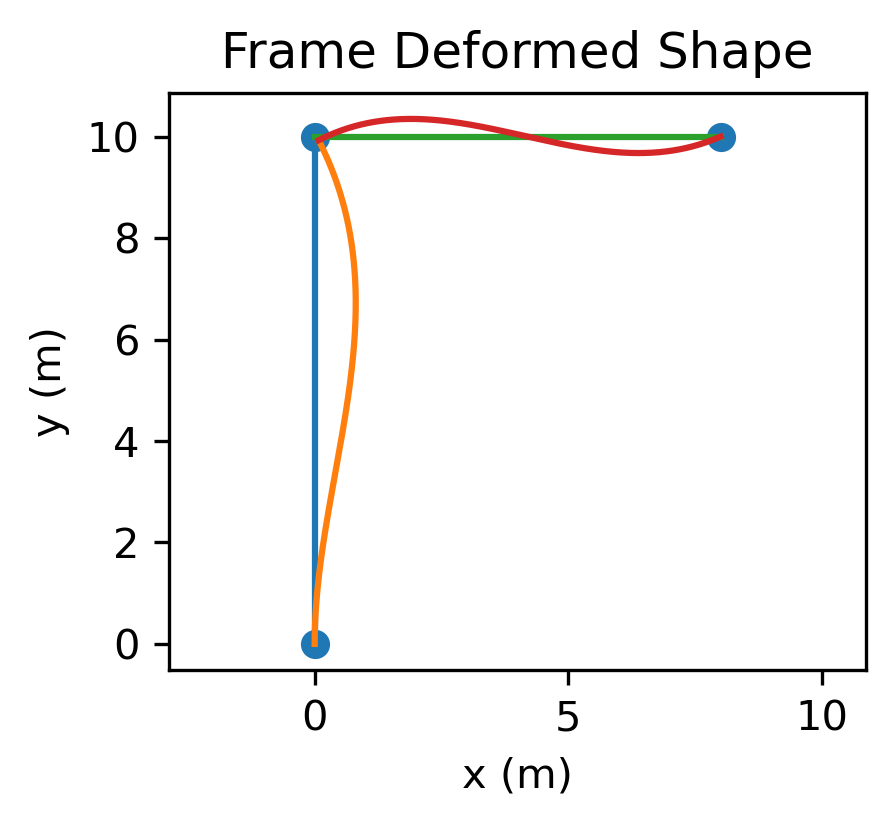

In [31]:
# Define nodes, elements, and U for your beam example

nodes = {
    1: (0.0, 0.0),
    2: (0.0, 10.0),
    3: (8.0, 10.0)
}
elements = {
    1: (1, 2),
    2: (2, 3)
}
U = [
    0.0, 0.0, 0.0,
    0.00395368, -0.00359954, 0.02534228,
    0.0, 0.0, 0.02179419
]

plot_deformed_frame_2d(nodes, elements, U, scale=20, npts=500)
# Then call plot_deformed_frame_2d(...)